<a href="https://colab.research.google.com/github/Yojana-1808/E-commerce-Customer-Segmentation/blob/main/E_commerce_Customer_Behavior_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

**Load Dataset**

In [ ]:
df = pd.read_csv("/content/E-commerce Customer Behavior - Sheet1-selected-columns.csv")

print(df.head())

print(df.info())

print(df.describe())

   Customer ID  Gender  Age           City Membership Type  Total Spend  \
0          101  Female   29       New York            Gold      1120.20   
1          102    Male   34    Los Angeles          Silver       780.50   
2          103  Female   43        Chicago          Bronze       510.75   
3          104    Male   30  San Francisco            Gold      1480.30   
4          105    Male   27          Miami          Silver       720.40   

   Items Purchased  Average Rating  Discount Applied  Days Since Last Purchase  
0               14             4.6              True                        25  
1               11             4.1             False                        18  
2                9             3.4              True                        42  
3               19             4.7             False                        12  
4               13             4.0              True                        55  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 

**Check Missing Values**

In [ ]:
print(df.isnull().sum())

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
dtype: int64


**Remove Duplicates**

In [ ]:
df = df.drop_duplicates()

**EDA**
***Gender Distribution***

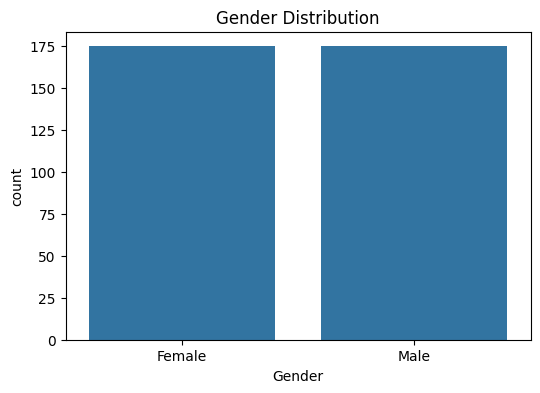

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

**Membership Type**

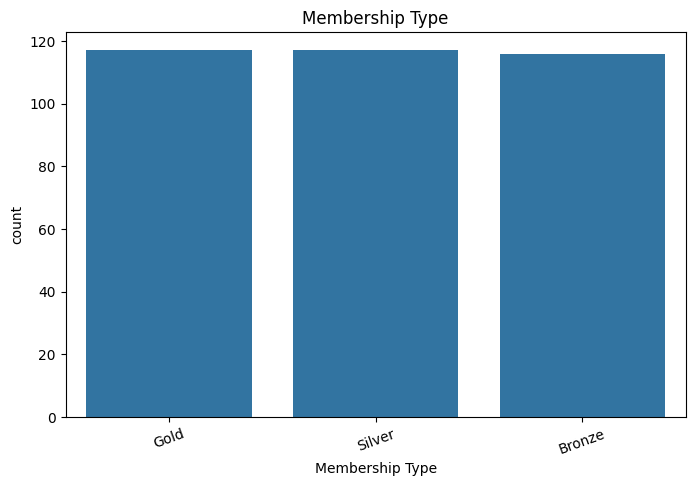

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Membership Type', data=df)
plt.title("Membership Type")
plt.xticks(rotation=20)
plt.show()

**City-wise Customers**

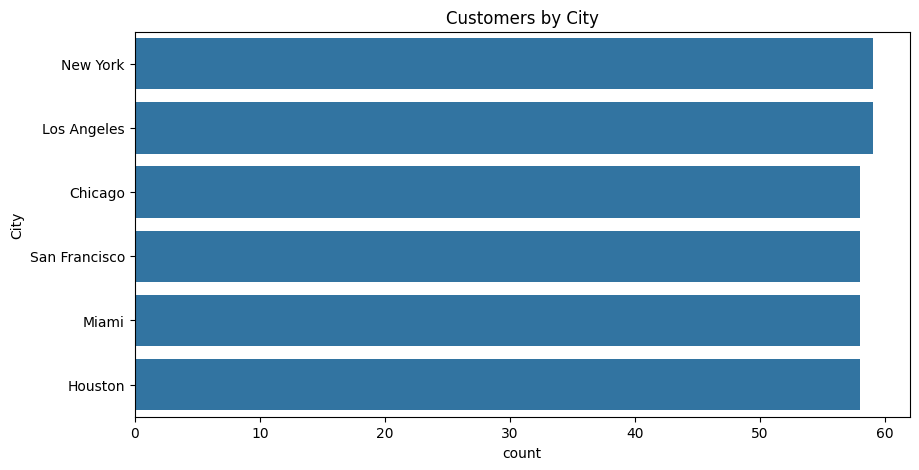

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(y='City', data=df)
plt.title("Customers by City")
plt.show()

**Discount Applied**

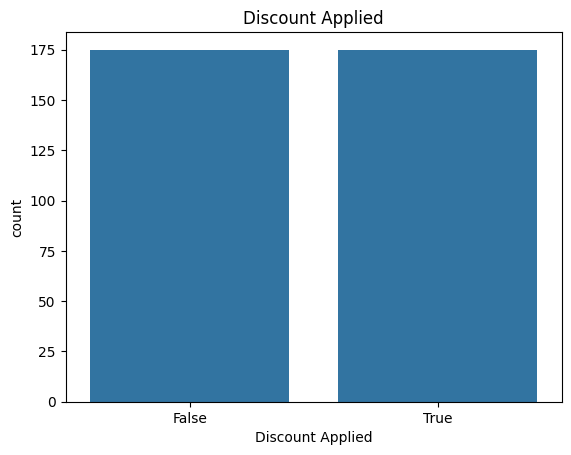

In [ ]:
sns.countplot(x='Discount Applied',data=df)
plt.title("Discount Applied")
plt.show()

**Correlation Heatmap**

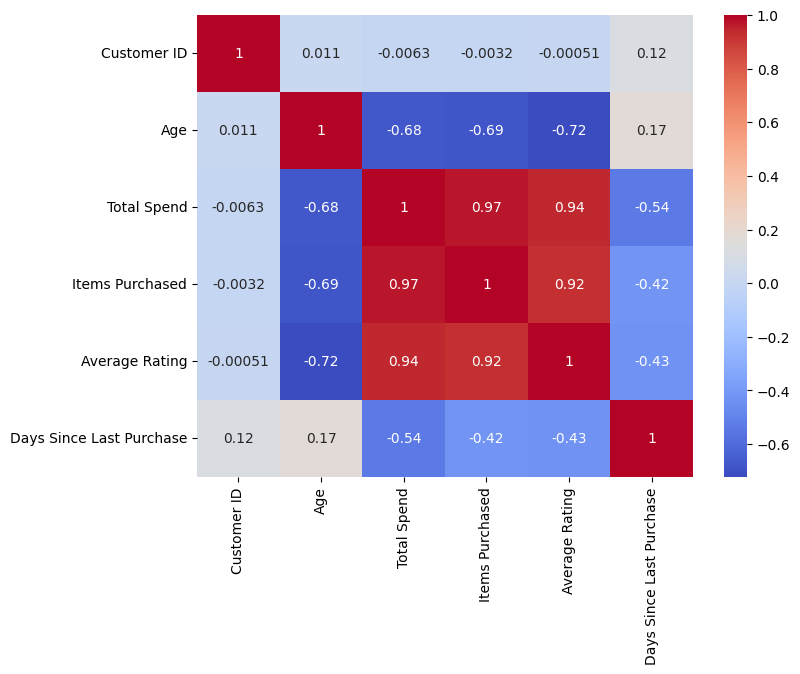

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
df.select_dtypes(include=np.number).corr(),
annot=True,
cmap="coolwarm")

plt.show()

**Select Features**

In [ ]:
X = df[[
'Age',
'Total Spend',
'Items Purchased',
'Average Rating',
'Days Since Last Purchase'
]]

**Standardization**

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**Elbow Method**

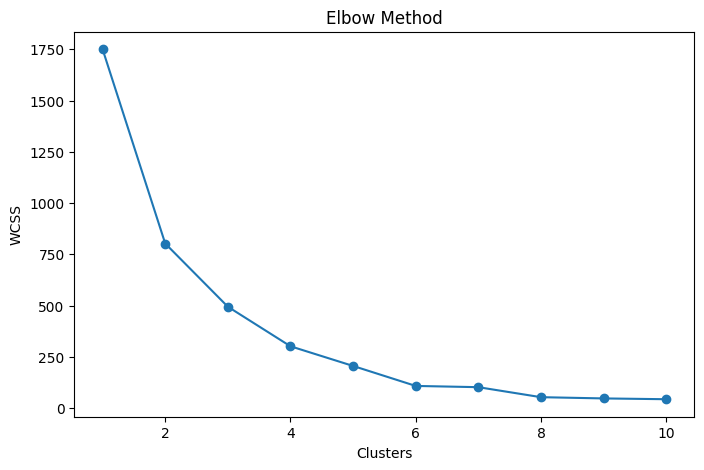

In [ ]:
wcss=[]

for i in range(1,11):

    model=KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

**K-Means**

In [ ]:
kmeans = KMeans(
n_clusters=4,
random_state=42
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

**Silhouette Score**

In [ ]:
score = silhouette_score(
X_scaled,
df["Cluster"]
)

print(score)

0.5461293384394464


**PCA**

In [ ]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

df["PCA1"] = pca_data[:,0]

df["PCA2"] = pca_data[:,1]

**PCA Visualization**

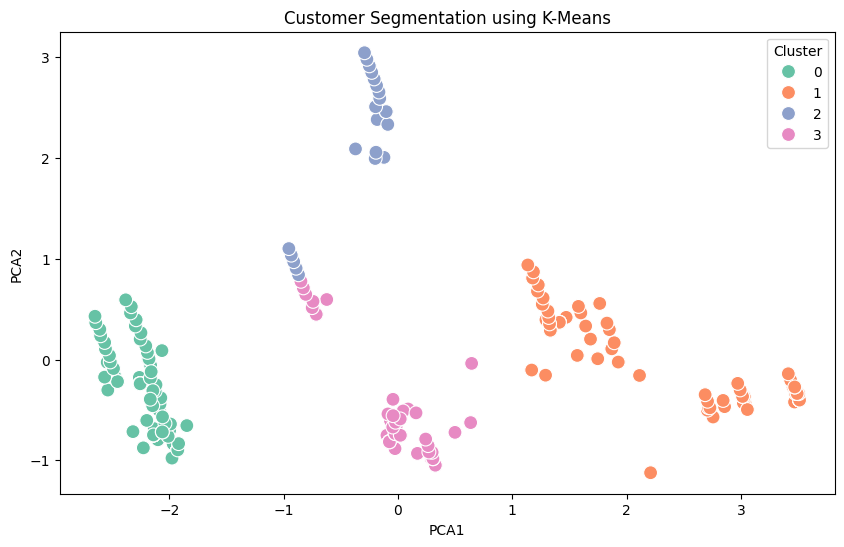

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
x="PCA1",
y="PCA2",
hue="Cluster",
palette="Set2",
data=df,
s=100
)

plt.title("Customer Segmentation using K-Means")

plt.show()

**DBSCAN**

In [ ]:
dbscan = DBSCAN(
eps=1,
min_samples=5
)

df["DBSCAN"] = dbscan.fit_predict(X_scaled)

**DBSCAN Visualization**

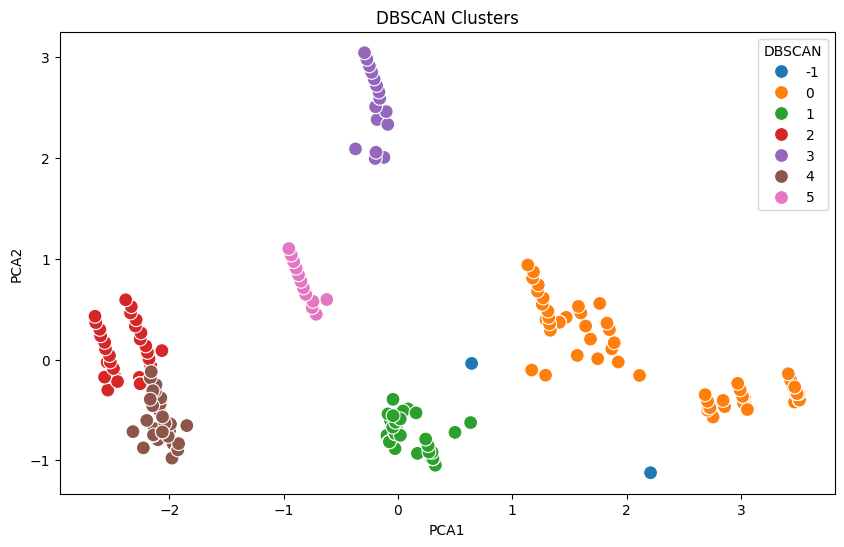

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
x="PCA1",
y="PCA2",
hue="DBSCAN",
palette="tab10",
data=df,
s=100
)

plt.title("DBSCAN Clusters")

plt.show()

**Cluster Profile**

In [ ]:
cluster_profile = df.groupby("Cluster")[[
'Age',
'Total Spend',
'Items Purchased',
'Average Rating',
'Days Since Last Purchase'
]].mean()

print(cluster_profile)

               Age  Total Spend  Items Purchased  Average Rating  \
Cluster                                                            
0        39.362069   473.388793         8.491379        3.325000   
1        29.923077  1311.144444        17.615385        4.675214   
2        27.461538   698.125641        12.410256        3.989744   
3        33.602564   773.585897        11.282051        4.082051   

         Days Since Last Purchase  
Cluster                            
0                       31.612069  
1                       17.940171  
2                       51.487179  
3                       19.641026  


**Save Result**

In [ ]:
df.to_csv(
"Customer_Segmentation_Result.csv",
index=False
)